# Notebook 03 - Unconstrained neural survival model

The arm with no structural constraint at all. A network maps `(x, t)` straight
to a survival probability through a sigmoid:

    S(x, t) = sigmoid( f(x, t) ) in (0, 1)

The sigmoid bounds the output to a valid probability. Nothing bounds it in `t`.
The network is free to predict `S(t + 1) > S(t)` for any borrower, which is what
makes this the reference point for the whole study: it is the arm that pays
nothing for structure and therefore sets the ceiling on discrimination that
constrained arms are measured against.

**What changed in this pass.** The training loop was the problem, not the model.
The previous version ran twenty full-batch Adam steps over 1.57M rows and called
each one an epoch. Its recorded loss went 0.5800, 0.4101, 0.4129, 0.4133 -- it
stopped improving after the fifth step and then got worse, and there was no
validation split to notice. Training now runs through `src.torch_arms`:
shuffled minibatches, real passes over the data, a validation slice held out of
train, and early stopping with best-weight restoration.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.common import (load_data, make_split, build_features, describe_split,
                        survival_arrays, subsample_train, HORIZONS, SEED,
                        SUBSAMPLE_N, RESULTS_DIR)
from src.evaluate import evaluate_arm, save_arm_results, plot_calibration
from src.monotonicity import (audit_monotonicity, cumhaz_from_survival,
                              format_audit, plot_worst_curves)
from src.torch_arms import (set_seed, as_tensors, train_minibatch, plot_history,
                            batched_survival)

set_seed(SEED)
torch.set_num_threads(max(1, (torch.get_num_threads() or 4)))
RESULTS_DIR.mkdir(exist_ok=True)
print("torch", torch.__version__, "| threads", torch.get_num_threads())

torch 2.9.1+cpu | threads 8


## The shared protocol

Identical split and identical feature matrix to every other arm, from
`src/common.py`. The scaler is fitted on train only.

**Training subsample.** This arm is fitted on a stratified draw of
`SUBSAMPLE_N = 300,000` training rows rather than all 1,573,299. Full-data
training did not finish in acceptable wall-clock on this machine, and a complete
comparison on a subsample is worth more than an empty cell on the full data. The
draw preserves the event rate exactly, and the size is recorded in this arm's
results JSON so the master table shows where each arm sits. The **test split is
untouched**: every arm is scored on the same 674,272 held-out loans, so the
metrics remain comparable across the whole table.

In [2]:
df = load_data()
train_df_full, test_df = make_split(seed=SEED)
train_df = subsample_train(train_df_full, n=SUBSAMPLE_N)

print(f"full train rows      : {len(train_df_full):,}")
print(f"subsampled train rows: {len(train_df):,}  "
      f"(event rate {train_df['event'].mean():.6f} vs "
      f"{train_df_full['event'].mean():.6f} full)")
print(f"test rows            : {len(test_df):,}  (not subsampled)")
print()

feat = build_features(train_df, test_df)

t_tr, e_tr = survival_arrays(train_df)
t_te, e_te = survival_arrays(test_df)

print(describe_split(train_df, test_df).to_string(index=False))
print()
print("design matrix:", feat.X_train.shape, feat.X_test.shape)
print("features:", feat.names)

X_tr, T_tr, E_tr = as_tensors(feat.X_train, t_tr, e_tr)
X_te, T_te, E_te = as_tensors(feat.X_test, t_te, e_te)

full train rows      : 1,573,299
subsampled train rows: 300,000  (event rate 0.128023 vs 0.128023 full)
test rows            : 674,272  (not subsampled)



split   rows  event_rate  median_time_m
train 300000    0.128023           17.3
 test 674272    0.127732           18.2

design matrix: (300000, 14) (674272, 14)
features: ['annual_inc', 'dti', 'loan_amnt', 'int_rate', 'term', 'grade', 'emp_length_missing', 'emp_length', 'home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT']


## Model

A two-hidden-layer MLP on `[x, t]`. Time enters divided by 60 so it arrives on
roughly the same scale as the standardised features rather than as a raw number
up to 60; the same rescaling is applied in notebook 04, so it cannot favour
either arm.

The only structural property this architecture guarantees is `S in (0, 1)`. It
guarantees nothing about the shape of `S` in `t`.

In [3]:
TIME_SCALE = 60.0

class UnconstrainedSurvivalNN(nn.Module):
    """Maps (x, t) -> S in (0,1). No monotonicity in t is imposed."""

    def __init__(self, d, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x, t):
        z = torch.cat([x, t / TIME_SCALE], dim=1)
        return torch.sigmoid(self.net(z))


model = UnconstrainedSurvivalNN(X_tr.shape[1])
print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))

UnconstrainedSurvivalNN(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)
parameters: 5249


## Loss

The arm keeps its original objective: a binary cross-entropy that reads the
observation at its recorded time as *defaulted* or *did not default*.

$$\mathcal{L} = -\delta \log(1 - S(t)) - (1-\delta)\log S(t)$$

This is **not** the survival log-likelihood. It pushes every censored
observation towards `S(t) = 1`, treating "not yet defaulted when last seen" as
"never defaults", instead of as still at risk beyond `t`.

**A confound to be explicit about.** Notebook 04 changes two things at once
relative to this notebook: it adds the soft monotonicity penalty *and* it swaps
this objective for a proper survival negative log-likelihood. Any difference
between the two arms is therefore attributable to the pair, not to the
constraint alone. Isolating the cost of the constraint requires a further arm --
the same survival likelihood with the penalty weight set to zero -- which is not
built in this pass. Until it exists, the notebook-03-versus-notebook-04 gap
should not be read as the price of monotonicity.

In [4]:
def loss_fn(S, e, eps=1e-6):
    return torch.mean(-e * torch.log(1 - S + eps) - (1 - e) * torch.log(S + eps))


def step_loss(model, xb, tb, eb):
    S = model(xb, tb)
    loss = loss_fn(S, eb)
    return loss, {"data": float(loss.detach())}

## Training

Minibatches of 8192, 10% of train held out for the stopping rule, patience of 5
epochs, best weights restored.

The epoch ceiling is 60 and is **not** the intended stopping rule. What should
end training is early stopping, on a validation slice held out of train, once
the loss stops falling by a margin that matters (`min_delta=1e-4`). An arm that
runs into the ceiling instead has been cut off mid-descent, and reporting its
metrics would measure a truncated optimisation rather than the model. The run
prints which of the two happened, and `stopped_early` is recorded in the results
JSON so the comparison table can be checked.

In [5]:
set_seed(SEED)
model = UnconstrainedSurvivalNN(X_tr.shape[1])

history = train_minibatch(model, step_loss, X_tr, T_tr, E_tr,
                          batch_size=8192, max_epochs=60, lr=1e-3,
                          val_frac=0.1, patience=5, seed=SEED, monitor="data")

train rows 270,000 | val rows 30,000 | batch 8192 | 33 steps/epoch


epoch   1 | train 0.49737 | val 0.37622 | data=0.37622 | * (6s)


epoch   2 | train 0.36630 | val 0.35172 | data=0.35172 | * (12s)


epoch   3 | train 0.35791 | val 0.34956 | data=0.34956 | * (18s)


epoch   4 | train 0.35619 | val 0.34827 | data=0.34827 | * (24s)


...

epoch  56 | train 0.33591 | val 0.33120 | data=0.33120 | * (284s)


epoch  57 | train 0.33581 | val 0.33132 | data=0.33132 |   (288s)


epoch  58 | train 0.33577 | val 0.33127 | data=0.33127 |   (292s)


epoch  59 | train 0.33572 | val 0.33171 | data=0.33171 |   (297s)


epoch  60 | train 0.33557 | val 0.33131 | data=0.33131 |   (301s)
restored weights from epoch 56 | 1980 gradient steps in 301s


 epoch  train_total  val_total  steps   seconds
     1      0.49737    0.37622     33   6.28930
     2      0.36630    0.35172     66  12.03027
     3      0.35791    0.34956     99  18.12124
     4      0.35619    0.34827    132  23.55189
     5      0.35488    0.34714    165  29.25572
     6      0.35354    0.34595    198  34.55800
     7      0.35218    0.34474    231  40.33948
     8      0.35078    0.34350    264  45.70159
     9      0.34935    0.34250    297  50.96013
    10      0.34797    0.34127    330  56.42821
    11      0.34675    0.34066    363  62.00378
    12      0.34592    0.33997    396  67.64989
    13      0.34530    0.33957    429  73.03145
    14      0.34481    0.33929    462  78.18315
    15      0.34437    0.33890    495  83.22801
    16      0.34398    0.33869    528  88.63863
    17      0.34375    0.33835    561  93.57613
    18      0.34352    0.33827    594  98.45803
    19      0.34322    0.33825    627 103.34713
    20      0.34295    0.33781    660 10

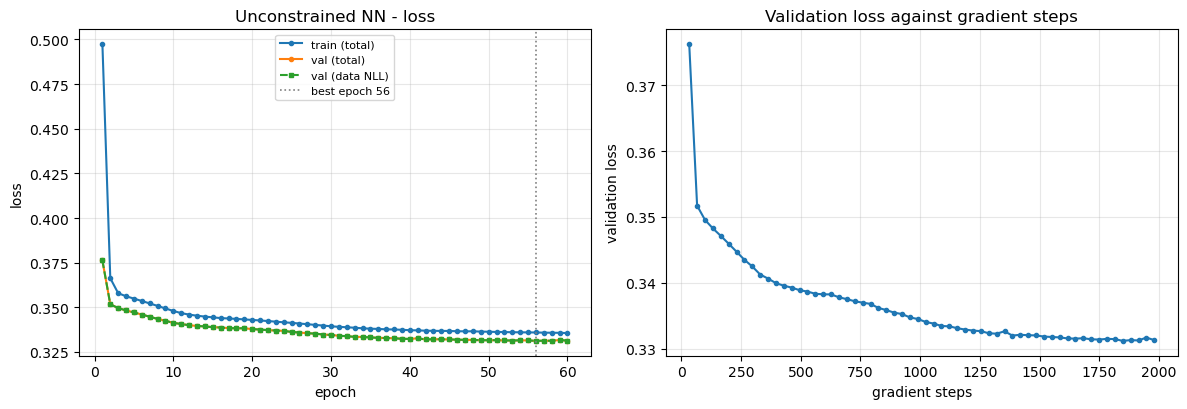

In [6]:
hist_df = pd.DataFrame({k: v for k, v in history.items() if isinstance(v, list)})
hist_df.to_csv(RESULTS_DIR / "nb03_training_history.csv", index=False)
print(hist_df[["epoch", "train_total", "val_total", "steps", "seconds"]]
      .round(5).to_string(index=False))
print()
print(f"gradient steps taken: {history['total_steps']:,}  "
      f"(the previous version of this notebook took 20)")
print(f"stopped early: {history['stopped_early']}  "
      f"(False means the epoch ceiling bound and the arm is undertrained)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
plot_history(history, title="Unconstrained NN - loss", ax=axes[0])
axes[1].plot(hist_df["steps"], hist_df["val_total"], "o-", ms=3)
axes[1].set_xlabel("gradient steps"); axes[1].set_ylabel("validation loss")
axes[1].set_title("Validation loss against gradient steps"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Survival curves

Five held-out borrowers over a 60-month horizon. With no constraint in `t`,
nothing keeps these curves from rising.

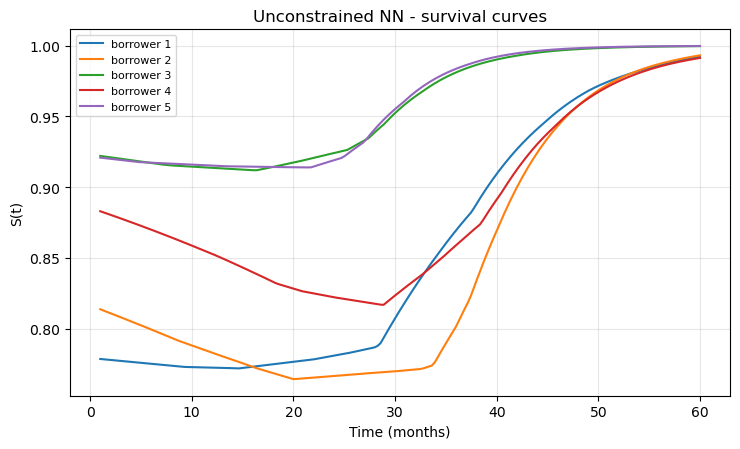

largest increase in S between adjacent grid points, per borrower:
[0.00375  0.005846 0.002196 0.003355 0.002658]


In [7]:
predict_survival = batched_survival(lambda x, t: model(x, t))

grid = np.linspace(1, 60, 200)
Sc = predict_survival(feat.X_test[:5], grid)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for i in range(5):
    ax.plot(grid, Sc[i], lw=1.5, label=f"borrower {i + 1}")
ax.set_xlabel("Time (months)"); ax.set_ylabel("S(t)")
ax.set_title("Unconstrained NN - survival curves")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

rises = np.diff(Sc, axis=1)
print("largest increase in S between adjacent grid points, per borrower:")
print(np.round(rises.max(axis=1), 6))

## Monotonicity audit

The study's central measurement: 1,000 held-out borrowers, cumulative hazard on
a half-month grid from 1 to 60 months, counting every point where
`dLambda/dt < 0`.

In [8]:
mono, detail = audit_monotonicity(
    cumhaz_from_survival(predict_survival), feat.X_test,
    name="Unconstrained NN", n_borrowers=1000, return_detail=True)

print(format_audit(pd.DataFrame([mono])).T.to_string(header=False))

arm                      Unconstrained NN
n_borrowers                          1000
n_grid_points                         119
pct_points_violating                72.81
pct_borrowers_violating             100.0
max_violation_dLam_dt             0.08179
max_violation_dLam                0.04089
max_survival_increase             0.02019


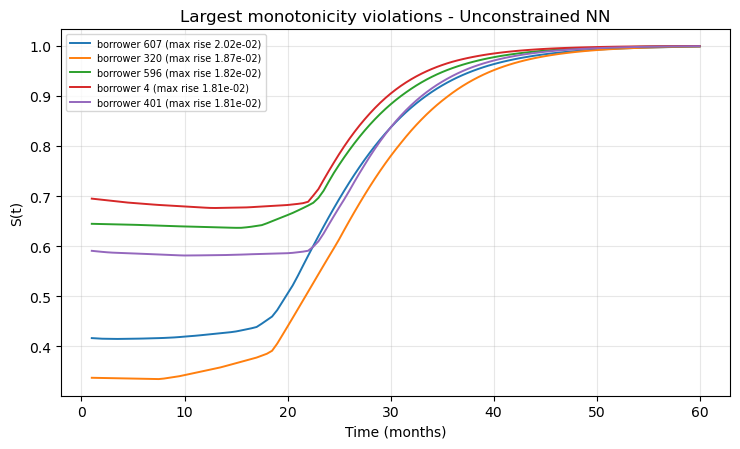

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
plot_worst_curves(detail, n_curves=5, name="Unconstrained NN", ax=ax)
plt.tight_layout(); plt.show()

## Evaluation

Scored through the shared harness: Harrell's and Uno's C, time-dependent AUC at
12 / 24 / 36 months computed exactly as notebook 02 computes its binary AUCs,
integrated Brier score over 1-60 months, and decile calibration.

In [10]:
result = evaluate_arm(predict_survival, feat.X_test, test_df, train_df,
                     name="Unconstrained NN")
print(result)
print()
print("notes:", result.notes)
save_arm_results(result, mono, extra={"best_epoch": history["best_epoch"],
                                      "total_steps": history["total_steps"],
                                      "stopped_early": history["stopped_early"],
                                      "epochs_run": history["epoch"][-1],
                                      "max_epochs": history["max_epochs"],
                                      "subsample_n": SUBSAMPLE_N,
                                      "n_train_used": int(len(train_df))})

EvalResult(Unconstrained NN)
             arm  auc_12m  auc_24m  auc_36m  pct_borrowers_any_PD_inversion  largest_PD_reversal  pct_borrowers_PD12_gt_PD24  pct_borrowers_PD24_gt_PD36  c_harrell    c_uno  ibs_1_60m
Unconstrained NN 0.687856 0.678591 0.638768                       97.515246             0.402271                   60.590237                   97.515246    0.65977 0.636198    0.18185

notes: {'n_test': 674272, 'n_train': 300000, 'backends': {'lifelines': True, 'scikit-survival': False}, 'c_index_n': 25000, 'ibs_n': 100000}


WindowsPath('C:/Users/arora/Downloads/credit_survival_project-main (2)/results/unconstrained_nn.json')

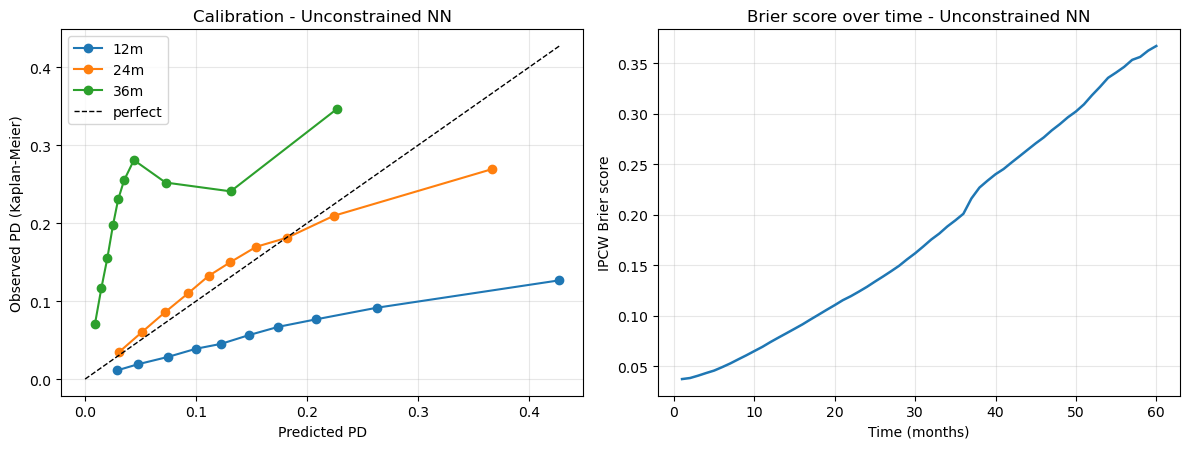

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
plot_calibration(result, ax=axes[0])
axes[1].plot(result.brier["month"], result.brier["brier"], lw=1.8)
axes[1].set_xlabel("Time (months)"); axes[1].set_ylabel("IPCW Brier score")
axes[1].set_title("Brier score over time - Unconstrained NN"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Summary

This arm buys its discrimination without paying anything for structure. The
monotonicity audit above records what that costs in validity, and the same audit
runs unchanged on every other arm, so the numbers sit in one table.

Two caveats carry forward. The objective is a binary cross-entropy rather than a
survival likelihood, so censored loans are pushed towards `S = 1`; and because
notebook 04 changes both the objective and the penalty, the gap between these
two notebooks is not a clean measurement of what the constraint costs.